In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader

from torchvision import models
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

from transformers import AutoImageProcessor, AutoModelForImageClassification

from PIL import Image
import matplotlib.pyplot as plt

import requests
import random
import os
import glob
import shutil
import pandas as pd
import re

import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/hub/parrots.png"
image = Image.open(requests.get(url, stream=True).raw)

processor = AutoImageProcessor.from_pretrained("Falconsai/nsfw_image_detection")
model = AutoModelForImageClassification.from_pretrained("Falconsai/nsfw_image_detection")

with torch.no_grad():
    inputs = processor(images=image, return_tensors="pt")
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_id = logits.argmax(-1).item()

print("Clase predicha:", model.config.id2label[predicted_class_id])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Clase predicha: normal


In [ ]:
print(model)

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [ ]:
for param in model.vit.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True


In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print("Entrenable:", name)


Entrenable: classifier.weight
Entrenable: classifier.bias


In [ ]:


class RandomRotate90PIL:
    def __call__(self, img):
        angle = random.choice([0, 90, 180, 270])
        return img.rotate(angle)


In [ ]:
pat = "/content/drive/MyDrive/Transfer learning/png_224"

train_augment = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    RandomRotate90PIL(),
])

# ===== Transform wrappers =====
def train_transform(image):
    image = train_augment(image)
    return processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

def eval_transform(image):
    return processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

# ===== Datasets =====
train_dataset = ImageFolder(f"{pat}/train", transform=train_transform)
val_dataset   = ImageFolder(f"{pat}/val", transform=eval_transform)
test_dataset  = ImageFolder(f"{pat}/test", transform=eval_transform)

# ===== DataLoaders =====
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)


In [ ]:
import os
import torch
import torch.nn as nn

# ===== Contar imágenes por clase =====
train_dir = pat + "/train"

class_counts = {}
for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Conteo por clase:", class_counts)



Conteo por clase: {'clase0': 3731, 'clase1': 552}


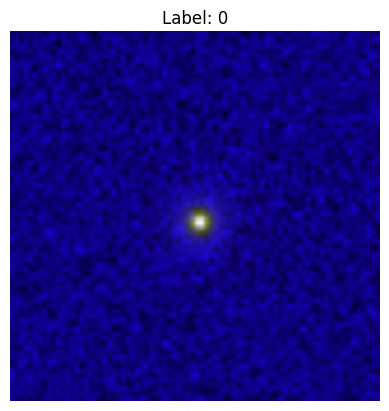

In [ ]:
# Mostrar una imagen del train_loader (desnormalizada para visualización)


# Obtener un batch
images, labels = next(iter(train_loader))

# Tomar la primera imagen del batch
img_tensor = images[0]  # shape (3, H, W)

# El processor normaliza; necesitamos desnormalizar para visualizar correctamente
mean = torch.tensor(processor.image_mean).view(3, 1, 1)
std = torch.tensor(processor.image_std).view(3, 1, 1)

img_denorm = img_tensor * std + mean
img_denorm = img_denorm.clamp(0, 1)

# Convertir a HWC para matplotlib
img_np = img_denorm.permute(1, 2, 0).cpu().numpy()

plt.figure()
plt.imshow(img_np)
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()


In [ ]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_sum = cm.sum(axis=1, keepdims=True)
    cm_perc = np.divide(cm, cm_sum, where=cm_sum != 0)

    fig, ax = plt.subplots()
    ax.imshow(cm_perc, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(["Good", "Bad"])
    ax.set_yticklabels(["Good", "Bad"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.title(title)

    for i in range(2):
        for j in range(2):
            color = "white" if cm_perc[i, j] > 0.5 else "black"
            ax.text(
                j, i,
                f"{cm[i, j]}\n({cm_perc[i, j]*100:.1f}%)",
                ha="center", va="center", color=color, fontsize=10
            )

    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.show()
    return cm

def print_metrics(y_true, y_pred, name):
    print(f"\n=== {name} Metrics (Test) ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("Precision (Bad=1):", precision_score(y_true, y_pred, pos_label=1, zero_division=0))
    print("Recall (Bad=1):", recall_score(y_true, y_pred, pos_label=1, zero_division=0))
    print("F1 (Bad=1):", f1_score(y_true, y_pred, pos_label=1, zero_division=0))
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["Good", "Bad"], zero_division=0))

In [ ]:

# ===== Device =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ===== Calcular pesos =====
counts = torch.tensor(
    [class_counts["clase0"], class_counts["clase1"]],
    dtype=torch.float32
)

n_total = counts.sum()
n_classes = len(counts)

class_weights = (n_total / (n_classes * counts)).to(device)

print("Class weights:", class_weights)

# ===== Loss con pesos =====
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ===== Optimizer =====
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

num_epochs = 10

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=images)
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total

    # VALIDATION
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits
            loss = criterion(logits, labels)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )



Class weights: tensor([0.5740, 3.8795], device='cuda:0')
Epoch 1/10 | Train Loss: 1.6999 | Train Acc: 0.8681 | Val Loss: 0.4934 | Val Acc: 0.8294
Epoch 2/10 | Train Loss: 0.7663 | Train Acc: 0.7175 | Val Loss: 0.6180 | Val Acc: 0.6988
Epoch 3/10 | Train Loss: 0.6958 | Train Acc: 0.7147 | Val Loss: 0.6295 | Val Acc: 0.6911
Epoch 4/10 | Train Loss: 0.6746 | Train Acc: 0.7212 | Val Loss: 0.6138 | Val Acc: 0.7150
Epoch 5/10 | Train Loss: 0.6595 | Train Acc: 0.7497 | Val Loss: 0.5779 | Val Acc: 0.7579
Epoch 6/10 | Train Loss: 0.6506 | Train Acc: 0.7621 | Val Loss: 0.5953 | Val Acc: 0.7359
Epoch 7/10 | Train Loss: 0.6401 | Train Acc: 0.7745 | Val Loss: 0.5937 | Val Acc: 0.7483
Epoch 8/10 | Train Loss: 0.6311 | Train Acc: 0.7798 | Val Loss: 0.5625 | Val Acc: 0.7807
Epoch 9/10 | Train Loss: 0.6302 | Train Acc: 0.7948 | Val Loss: 0.5798 | Val Acc: 0.7712
Epoch 10/10 | Train Loss: 0.6245 | Train Acc: 0.7857 | Val Loss: 0.6037 | Val Acc: 0.7293


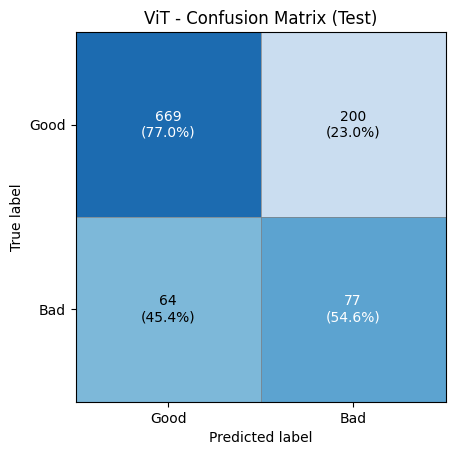


=== ViT Metrics (Test) ===
Accuracy: 0.7386138613861386
Balanced Accuracy: 0.6579748467709685
Precision (Bad=1): 0.2779783393501805
Recall (Bad=1): 0.5460992907801419
F1 (Bad=1): 0.3684210526315789

Classification Report:

              precision    recall  f1-score   support

        Good       0.91      0.77      0.84       869
         Bad       0.28      0.55      0.37       141

    accuracy                           0.74      1010
   macro avg       0.60      0.66      0.60      1010
weighted avg       0.82      0.74      0.77      1010



In [ ]:
vit_model = model

vit_model.to(device)
vit_model.eval()

y_true_vit = []
y_pred_vit = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        out = vit_model(pixel_values=images)
        logits = out.logits
        preds = torch.argmax(logits, dim=1)

        y_true_vit.append(labels.cpu().numpy())
        y_pred_vit.append(preds.cpu().numpy())

y_true_vit = np.concatenate(y_true_vit)
y_pred_vit = np.concatenate(y_pred_vit)

plot_cm(y_true_vit, y_pred_vit, "ViT - Confusion Matrix (Test)")
print_metrics(y_true_vit, y_pred_vit, "ViT")

In [ ]:

# ===== Device =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== Modelo CNN =====
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Congelar backbone
for param in model.parameters():
    param.requires_grad = False

# Reemplazar última capa (2 clases)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model.to(device)

# ===== Calcular class weights =====
counts = torch.tensor(
    [class_counts["clase0"], class_counts["clase1"]],
    dtype=torch.float32
)

n_total = counts.sum()
n_classes = len(counts)

class_weights = (n_total / (n_classes * counts)).to(device)

print("Class weights:", class_weights)

# ===== Loss ponderada =====
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ===== Optimizer (solo última capa) =====
optimizer = AdamW(model.fc.parameters(), lr=1e-4)

num_epochs = 10

for epoch in range(num_epochs):

    # =======================
    # TRAIN
    # =======================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total

    # =======================
    # VALIDATION
    # =======================
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Class weights: tensor([0.5740, 3.8795], device='cuda:0')
Epoch 1/10 | Train Loss: 0.7044 | Train Acc: 0.6337 | Val Loss: 0.6249 | Val Acc: 0.6559
Epoch 2/10 | Train Loss: 0.6612 | Train Acc: 0.6773 | Val Loss: 0.5680 | Val Acc: 0.7197
Epoch 3/10 | Train Loss: 0.6451 | Train Acc: 0.7056 | Val Loss: 0.5812 | Val Acc: 0.7054
Epoch 4/10 | Train Loss: 0.6364 | Train Acc: 0.6988 | Val Loss: 0.5616 | Val Acc: 0.7474
Epoch 5/10 | Train Loss: 0.6380 | Train Acc: 0.7252 | Val Loss: 0.5644 | Val Acc: 0.7255
Epoch 6/10 | Train Loss: 0.6306 | Train Acc: 0.7292 | Val Loss: 0.6132 | Val Acc: 0.6845
Epoch 7/10 | Train Loss: 0.6364 | Train Acc: 0.7187 | Val Loss: 0.5977 | Val Acc: 0.6854
Epoch 8/10 | Train Loss: 0.6262 | Train Acc: 0.7201 | Val Loss: 0.5081 | Val Acc: 0.7712
Epoch 9/10 | Train Loss: 0.6237 | Train Acc: 0.7306 | Val Loss: 0.5667 | Val Acc: 0.7178
Epoch 10/10 | Train Loss: 0.6147 | Train Acc: 0.7173 | Val Loss: 0.5177 | Val Acc: 0.7684


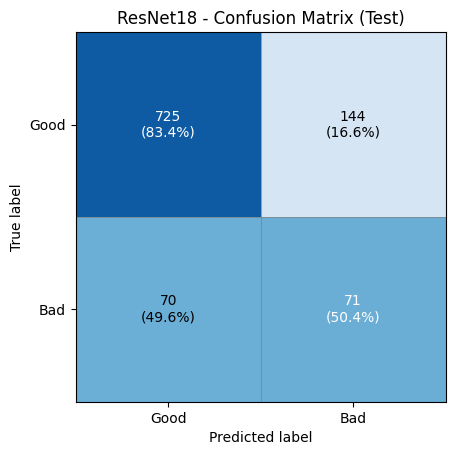


=== ResNet18 Metrics (Test) ===
Accuracy: 0.7881188118811882
Balanced Accuracy: 0.6689191946396362
Precision (Bad=1): 0.3302325581395349
Recall (Bad=1): 0.5035460992907801
F1 (Bad=1): 0.398876404494382

Classification Report:

              precision    recall  f1-score   support

        Good       0.91      0.83      0.87       869
         Bad       0.33      0.50      0.40       141

    accuracy                           0.79      1010
   macro avg       0.62      0.67      0.64      1010
weighted avg       0.83      0.79      0.81      1010



In [ ]:
resnet_model = model


resnet_model.to(device)
resnet_model.eval()

y_true_res = []
y_pred_res = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = resnet_model(images)
        preds = torch.argmax(logits, dim=1)

        y_true_res.append(labels.cpu().numpy())
        y_pred_res.append(preds.cpu().numpy())

y_true_res = np.concatenate(y_true_res)
y_pred_res = np.concatenate(y_pred_res)

plot_cm(y_true_res, y_pred_res, "ResNet18 - Confusion Matrix (Test)")
print_metrics(y_true_res, y_pred_res, "ResNet18")